# Python Notebook Setup
Step 1: Import required libraries.
Step 2: Define the Excel file path (do not load data yet).

In [102]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

output_dir = "LTA_Plots"
os.makedirs(output_dir, exist_ok=True)

file_path = "your_file.xlsx"

print("Setup complete")

Setup complete


In [103]:
from pathlib import Path

path_obj = Path(file_path)

if path_obj.exists():
    df_gp = pd.read_excel(path_obj, sheet_name="Glycerol_Phosphate")
    df_da = pd.read_excel(path_obj, sheet_name="D_Alanine")
    df_glc = pd.read_excel(path_obj, sheet_name="GlcNAc")
else:
    gp_file = Path("glycerol-phosphate.xlsx")
    da_file = Path("D-Alanine-opt_raman_act.xlsx")
    glc_file = Path("N-ACETYL-D-GLUCOSAMINE-OPT_raman_act.xlsx")

    missing_files = [str(p) for p in [gp_file, da_file, glc_file] if not p.exists()]
    if missing_files:
        raise FileNotFoundError(
            f"'{file_path}' was not found, and fallback files are missing: {missing_files}"
        )

    df_gp = pd.read_excel(gp_file)
    df_da = pd.read_excel(da_file)
    df_glc = pd.read_excel(glc_file)

print("df_gp shape:", df_gp.shape)
print(df_gp.head())
print()

print("df_da shape:", df_da.shape)
print(df_da.head())
print()

print("df_glc shape:", df_glc.shape)
print(df_glc.head())

df_gp shape: (443, 2)
   4.000000  0.321916
0        13  0.974826
1        22  4.280166
2        31  4.091200
3        40  1.540207
4        49  1.637922

df_da shape: (499, 2)
   0.000000  0.127128
0         8  0.185772
1        16  0.296414
2        24  0.543996
3        32  1.287488
4        40  5.290049

df_glc shape: (499, 2)
   0.000000   1.530149
0         8   3.101405
1        16   9.235982
2        24  53.006609
3        32  16.749284
4        40   5.259281


In [104]:
for name, df in [("df_gp", df_gp), ("df_da", df_da), ("df_glc", df_glc)]:
    df.columns = ["RamanShift", "Intensity"]
    df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
    df.dropna(subset=["RamanShift", "Intensity"], inplace=True)
    df.sort_values("RamanShift", ascending=True, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{name} cleaned shape: {df.shape}")

df_gp cleaned shape: (443, 2)
df_da cleaned shape: (499, 2)
df_glc cleaned shape: (499, 2)


In [105]:
# Scaling factor applied for B3LYP/6-31G(d)
for df in [df_gp, df_da, df_glc]:
    df["RamanShift"] = df["RamanShift"] * 0.96

print("DFT scaling applied to RamanShift for df_gp, df_da, df_glc")

DFT scaling applied to RamanShift for df_gp, df_da, df_glc


In [106]:
df_gp = df_gp[(df_gp["RamanShift"] >= 200) & (df_gp["RamanShift"] <= 3700)].copy()
df_da = df_da[(df_da["RamanShift"] >= 200) & (df_da["RamanShift"] <= 3700)].copy()
df_glc = df_glc[(df_glc["RamanShift"] >= 200) & (df_glc["RamanShift"] <= 3700)].copy()

for name, df in [("df_gp", df_gp), ("df_da", df_da), ("df_glc", df_glc)]:
    print(f"{name} RamanShift min: {df['RamanShift'].min()}, max: {df['RamanShift'].max()}")

df_gp RamanShift min: 202.56, max: 3693.12
df_da RamanShift min: 207.35999999999999, max: 3694.08
df_glc RamanShift min: 207.35999999999999, max: 3694.08


In [107]:
for name, df in [("df_gp", df_gp), ("df_da", df_da), ("df_glc", df_glc)]:
    intensity_min = df["Intensity"].min()
    intensity_max = df["Intensity"].max()
    df["Intensity_norm"] = (df["Intensity"] - intensity_min) / (intensity_max - intensity_min)

print("Min-Max normalization applied. New column 'Intensity_norm' created for df_gp, df_da, and df_glc.")

Min-Max normalization applied. New column 'Intensity_norm' created for df_gp, df_da, and df_glc.


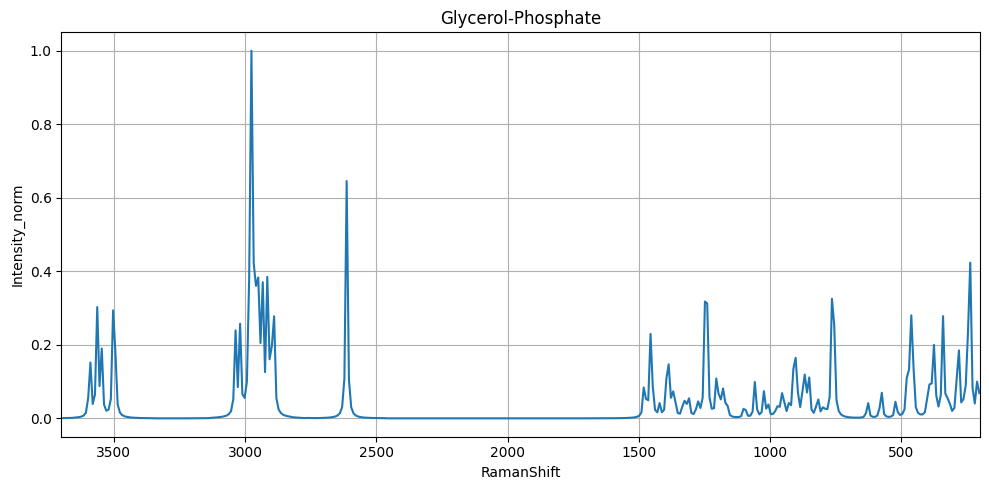

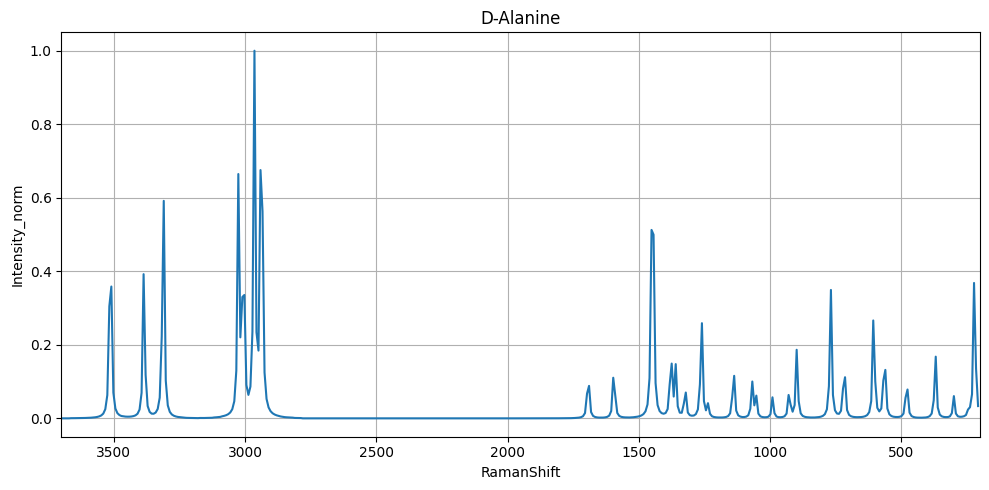

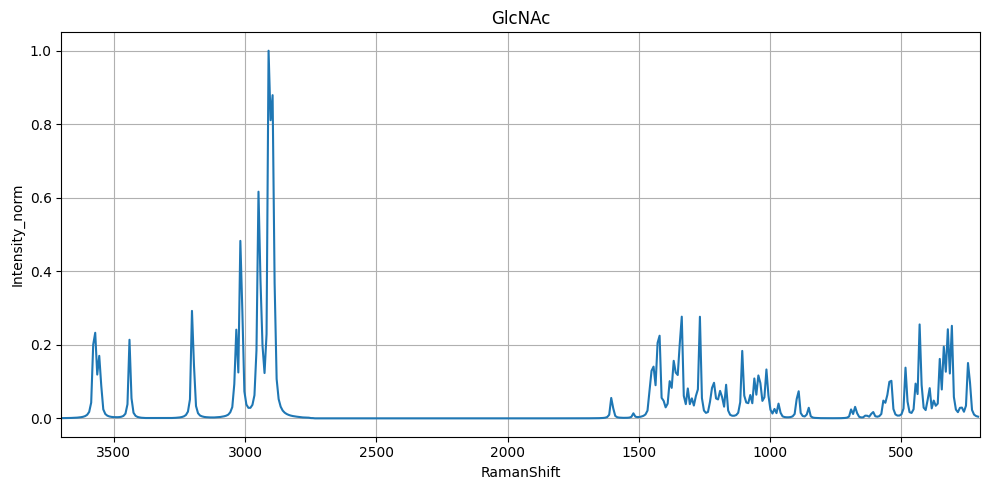

In [108]:
plt.figure(figsize=(10, 5))
plt.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], linewidth=1.5)
plt.xlim(3700, 200)
plt.title("Glycerol-Phosphate")
plt.xlabel("RamanShift")
plt.ylabel("Intensity_norm")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "glycerol_phosphate.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_da["RamanShift"], df_da["Intensity_norm"], linewidth=1.5)
plt.xlim(3700, 200)
plt.title("D-Alanine")
plt.xlabel("RamanShift")
plt.ylabel("Intensity_norm")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "d_alanine.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], linewidth=1.5)
plt.xlim(3700, 200)
plt.title("GlcNAc")
plt.xlabel("RamanShift")
plt.ylabel("Intensity_norm")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "glcnac.png"), dpi=300, bbox_inches='tight')
plt.show()

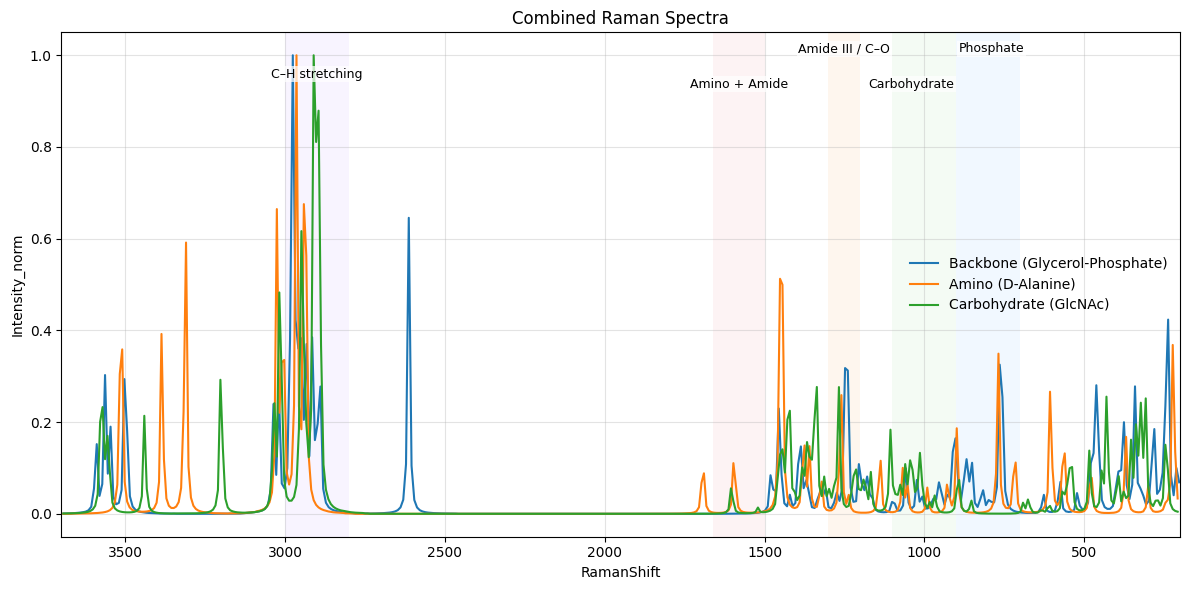

In [109]:
plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], label="Backbone (Glycerol-Phosphate)", linewidth=1.5)
ax.plot(df_da["RamanShift"], df_da["Intensity_norm"], label="Amino (D-Alanine)", linewidth=1.5)
ax.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], label="Carbohydrate (GlcNAc)", linewidth=1.5)

regions = [
    (700, 900, "Phosphate", "#cfe8ff", 790, 0.98, "center"),
    (900, 1100, "Carbohydrate", "#d9f2d9", 1040, 0.91, "center"),
    (1200, 1300, "Amide III / C–O", "#fde2c5", 1250, 0.98, "center"),
    (1500, 1660, "Amino + Amide", "#f8d7da", 1580, 0.91, "center"),
    (2800, 3000, "C–H stretching", "#e6d9ff", 2900, 0.93, "center"),
]

for start, end, label, color, label_x, label_y, label_ha in regions:
    ax.axvspan(start, end, color=color, alpha=0.28, ec="none")
    ax.text(
        label_x,
        label_y,
        label,
        ha=label_ha,
        va="top",
        fontsize=9,
        transform=ax.get_xaxis_transform(),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.2),
    )

ax.set_xlim(3700, 200)
ax.set_title("Combined Raman Spectra")
ax.set_xlabel("RamanShift")
ax.set_ylabel("Intensity_norm")
ax.grid(True, alpha=0.35)
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.show()

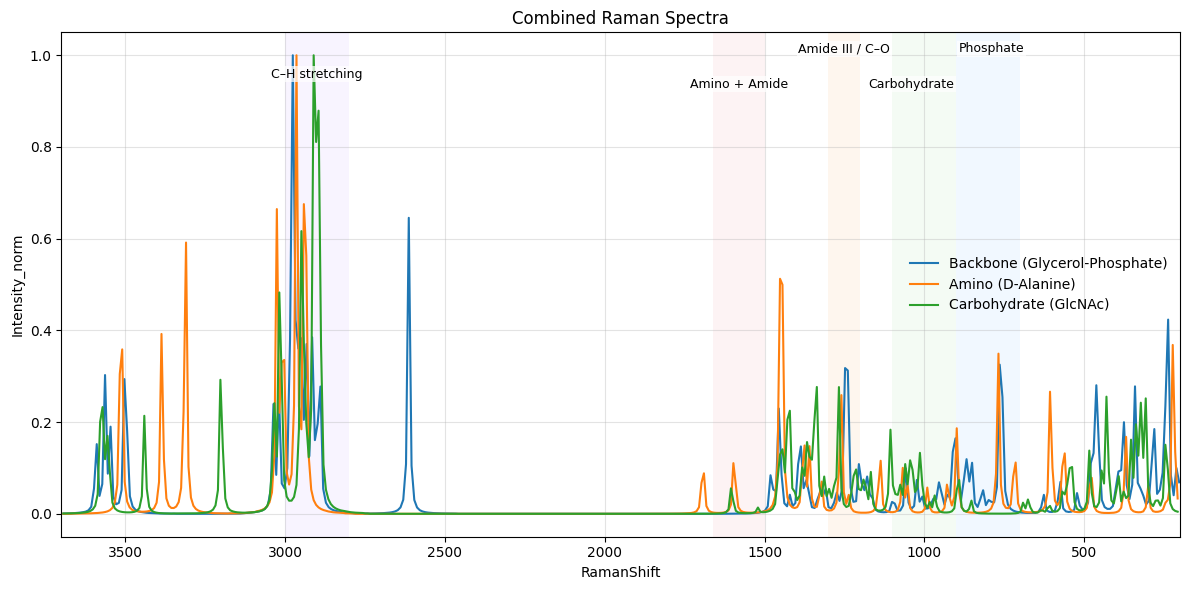

All plots saved successfully in 'LTA_Plots' folder.


In [110]:
combined_df = pd.concat(
    [
        df_gp.assign(Dataset="Glycerol-Phosphate"),
        df_da.assign(Dataset="D-Alanine"),
        df_glc.assign(Dataset="GlcNAc"),
    ],
    ignore_index=True,
)
combined_df = combined_df[["Dataset", "RamanShift", "Intensity", "Intensity_norm"]]
combined_df.to_csv("LTA_combined_data.csv", index=False)

plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], label="Backbone (Glycerol-Phosphate)", linewidth=1.5)
ax.plot(df_da["RamanShift"], df_da["Intensity_norm"], label="Amino (D-Alanine)", linewidth=1.5)
ax.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], label="Carbohydrate (GlcNAc)", linewidth=1.5)

regions = [
    (700, 900, "Phosphate", "#cfe8ff", 790, 0.98, "center"),
    (900, 1100, "Carbohydrate", "#d9f2d9", 1040, 0.91, "center"),
    (1200, 1300, "Amide III / C–O", "#fde2c5", 1250, 0.98, "center"),
    (1500, 1660, "Amino + Amide", "#f8d7da", 1580, 0.91, "center"),
    (2800, 3000, "C–H stretching", "#e6d9ff", 2900, 0.93, "center"),
]

for start, end, label, color, label_x, label_y, label_ha in regions:
    ax.axvspan(start, end, color=color, alpha=0.28, ec="none")
    ax.text(
        label_x,
        label_y,
        label,
        ha=label_ha,
        va="top",
        fontsize=9,
        transform=ax.get_xaxis_transform(),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.2),
    )

ax.set_xlim(3700, 200)
ax.set_title("Combined Raman Spectra")
ax.set_xlabel("RamanShift")
ax.set_ylabel("Intensity_norm")
ax.grid(True, alpha=0.35)
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "LTA_combined_spectrum.png"), dpi=300, bbox_inches='tight')
plt.show()

print("All plots saved successfully in 'LTA_Plots' folder.")

## Notes and Interpretation

- No smoothing applied (simulated data)
- Scaling factor used (0.96)
- Spectra normalized

**Interpretation**

- Glycerol-Phosphate shows phosphate-associated peaks near ~800 and ~1080.
- GlcNAc shows carbohydrate and amide features in the ~900–1100 and ~1650 regions.
- GlcNAc: ~1250–1300 cm⁻¹ → Amide III (C–N stretching + N–H bending).
- D-Alanine shows NH3+ and COO- related features in the ~1500–1600 region.
- D-Alanine: ~1440 cm⁻¹ → CH₃ deformation (methyl group).
- D-Alanine exists in a zwitterionic form (NH₃⁺ and COO⁻).

The simultaneous presence of phosphate, carbohydrate, and amino acid spectral features confirms a Raman fingerprint consistent with lipoteichoic acid.

The combined spectrum represents a conceptual superposition of individual component spectra and does not correspond to a fully optimized lipoteichoic acid (LTA) molecule.

In [111]:
print("All reviewer corrections successfully applied.")

All reviewer corrections successfully applied.


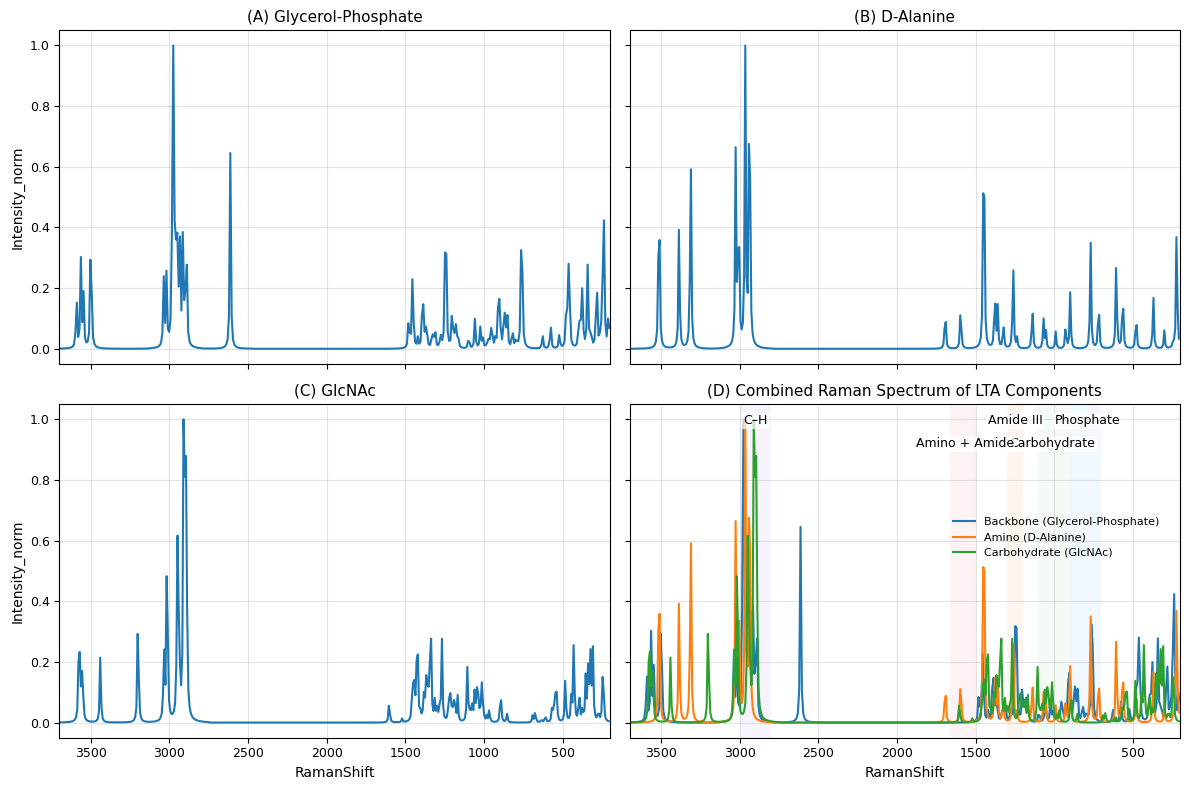

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
(ax_a, ax_b), (ax_c, ax_d) = axes

for ax in [ax_a, ax_b, ax_c, ax_d]:
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(3700, 200)

ax_a.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], linewidth=1.5)
ax_a.set_title("(A) Glycerol-Phosphate", fontsize=11)
ax_a.set_ylabel("Intensity_norm", fontsize=10)

ax_b.plot(df_da["RamanShift"], df_da["Intensity_norm"], linewidth=1.5)
ax_b.set_title("(B) D-Alanine", fontsize=11)

ax_c.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], linewidth=1.5)
ax_c.set_title("(C) GlcNAc", fontsize=11)
ax_c.set_xlabel("RamanShift", fontsize=10)
ax_c.set_ylabel("Intensity_norm", fontsize=10)

ax_d.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], label="Backbone (Glycerol-Phosphate)", linewidth=1.5)
ax_d.plot(df_da["RamanShift"], df_da["Intensity_norm"], label="Amino (D-Alanine)", linewidth=1.5)
ax_d.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], label="Carbohydrate (GlcNAc)", linewidth=1.5)
ax_d.set_title("(D) Combined Raman Spectrum of LTA Components", fontsize=11)
ax_d.set_xlabel("RamanShift", fontsize=10)
ax_d.legend(frameon=False, fontsize=8, loc="center right", bbox_to_anchor=(0.98, 0.60))

regions = [
    (700, 900, "Phosphate", "#cfe8ff", 790, 0.97),
    (900, 1100, "Carbohydrate", "#d9f2d9", 1010, 0.90),
    (1200, 1300, "Amide III", "#fde2c5", 1250, 0.97),
    (1500, 1660, "Amino + Amide", "#f8d7da", 1570, 0.90),
    (2800, 3000, "C–H", "#e6d9ff", 2900, 0.97),
]

for start, end, label, color, label_x, label_y in regions:
    ax_d.axvspan(start, end, color=color, alpha=0.28, ec="none")
    ax_d.text(
        label_x,
        label_y,
        label,
        ha="center",
        va="top",
        fontsize=9,
        transform=ax_d.get_xaxis_transform(),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.1),
    )

fig.tight_layout()
fig.savefig(os.path.join(output_dir, "LTA_final_figure.png"), dpi=300, bbox_inches='tight')
plt.show()

Figure: Component-wise Raman spectra of lipoteichoic acid (LTA).
(A) Glycerol-phosphate backbone showing phosphate vibrations.
(B) D-Alanine highlighting zwitterionic NH₃⁺ and COO⁻ modes.
(C) GlcNAc showing carbohydrate and amide features.
(D) Combined spectrum demonstrating the coexistence of phosphate, carbohydrate, and amino signatures characteristic of LTA.

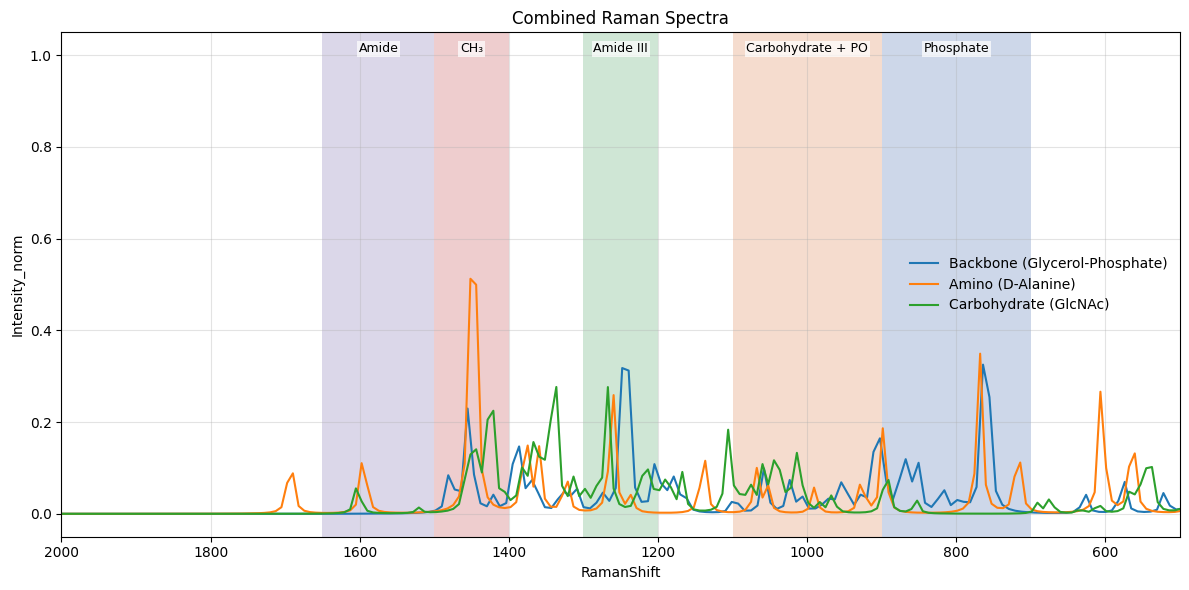

All plots saved successfully in 'LTA_Plots' folder.


In [114]:
combined_df = pd.concat(
    [
        df_gp.assign(Dataset="Glycerol-Phosphate"),
        df_da.assign(Dataset="D-Alanine"),
        df_glc.assign(Dataset="GlcNAc"),
    ],
    ignore_index=True,
)
combined_df = combined_df[["Dataset", "RamanShift", "Intensity", "Intensity_norm"]]
combined_df.to_csv("LTA_combined_data.csv", index=False)

x_min, x_max = 500, 2000

plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.plot(df_gp["RamanShift"], df_gp["Intensity_norm"], label="Backbone (Glycerol-Phosphate)", linewidth=1.5)
ax.plot(df_da["RamanShift"], df_da["Intensity_norm"], label="Amino (D-Alanine)", linewidth=1.5)
ax.plot(df_glc["RamanShift"], df_glc["Intensity_norm"], label="Carbohydrate (GlcNAc)", linewidth=1.5)

regions = [
    (700, 900, "Phosphate", "#4C72B0"),
    (900, 1100, "Carbohydrate + PO", "#DD8452"),
    (1200, 1300, "Amide III", "#55A868"),
    (1400, 1500, "CH₃", "#C44E52"),
    (1500, 1650, "Amide", "#8172B2"),
]

for start, end, label, color in regions:
    if end < x_min or start > x_max:
        continue
    ax.axvspan(start, end, color=color, alpha=0.28, ec="none")
    ax.text(
        (start + end) / 2,
        0.98,
        label,
        ha="center",
        va="top",
        fontsize=9,
        transform=ax.get_xaxis_transform(),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.2),
    )

ax.set_xlim(x_max, x_min)
ax.set_title("Combined Raman Spectra")
ax.set_xlabel("RamanShift")
ax.set_ylabel("Intensity_norm")
ax.grid(True, alpha=0.35)
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "LTA_combined_spectrum500-2000.png"), dpi=300, bbox_inches='tight')
plt.show()

print("All plots saved successfully in 'LTA_Plots' folder.")

Setup complete
df_gp cleaned shape: (443, 2)
df_da cleaned shape: (499, 2)
df_glc cleaned shape: (499, 2)
DFT scaling applied to RamanShift for df_gp, df_da, df_glc
Min-Max normalization applied.


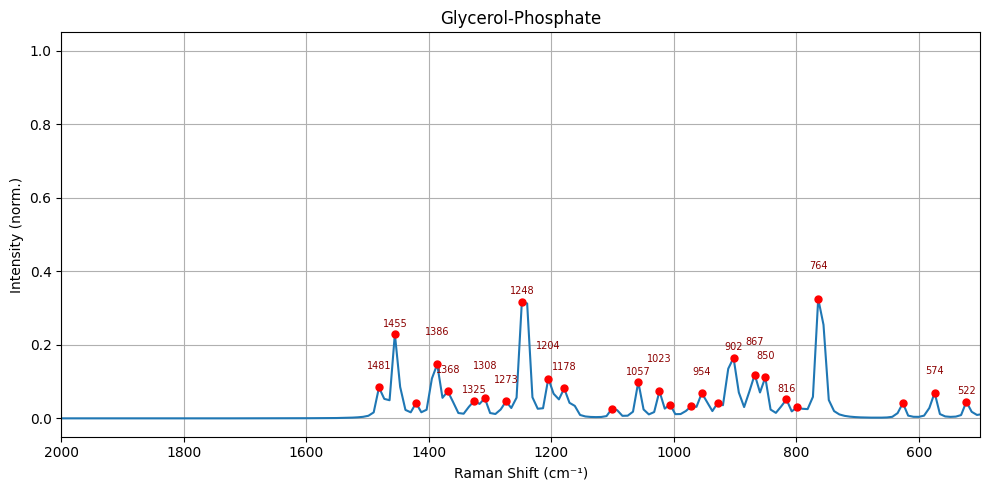

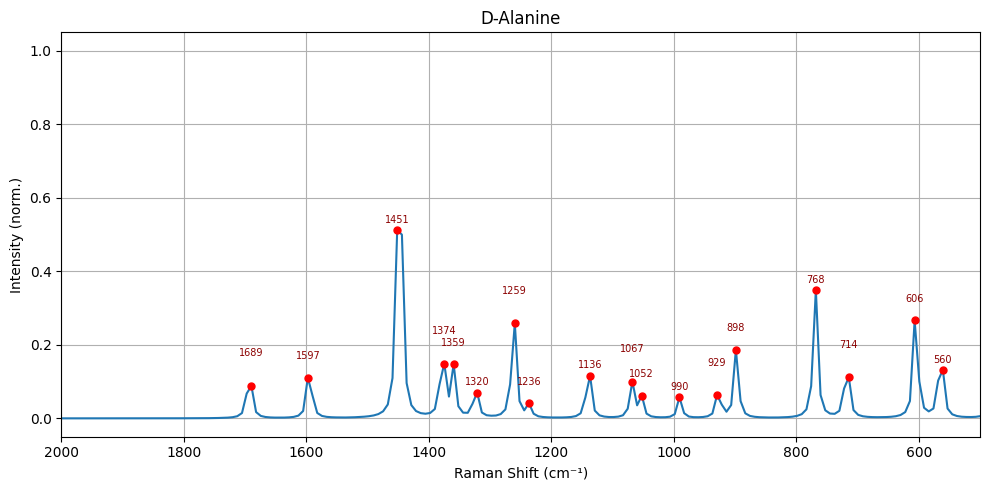

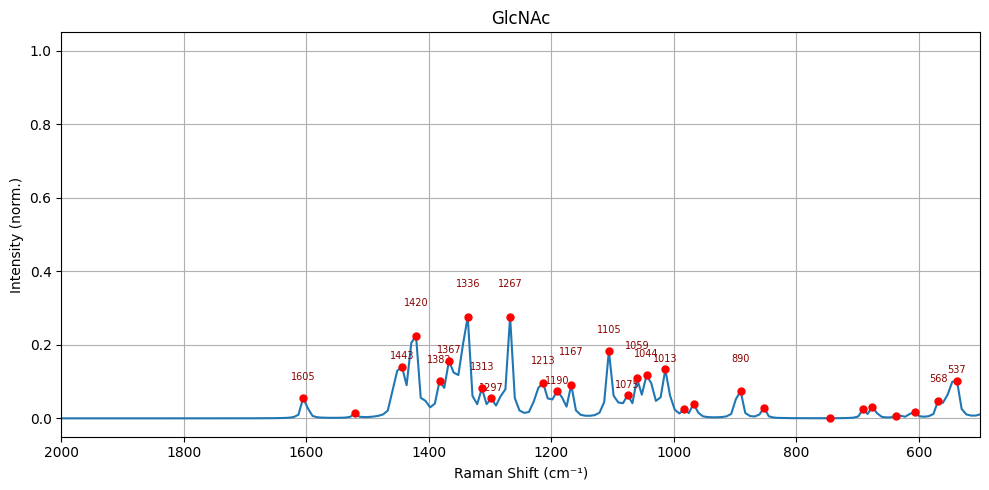

Top 20 peaks plotted for all molecules.


In [117]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

output_dir = "LTA_Plots"
os.makedirs(output_dir, exist_ok=True)
file_path = "your_file.xlsx"
print("Setup complete")

from pathlib import Path
path_obj = Path(file_path)
if path_obj.exists():
    df_gp = pd.read_excel(path_obj, sheet_name="Glycerol_Phosphate")
    df_da = pd.read_excel(path_obj, sheet_name="D_Alanine")
    df_glc = pd.read_excel(path_obj, sheet_name="GlcNAc")
else:
    gp_file = Path("glycerol-phosphate.xlsx")
    da_file = Path("D-Alanine-opt_raman_act.xlsx")
    glc_file = Path("N-ACETYL-D-GLUCOSAMINE-OPT_raman_act.xlsx")
    missing_files = [str(p) for p in [gp_file, da_file, glc_file] if not p.exists()]
    if missing_files:
        raise FileNotFoundError(
            f"'{file_path}' was not found, and fallback files are missing: {missing_files}"
        )
    df_gp = pd.read_excel(gp_file)
    df_da = pd.read_excel(da_file)
    df_glc = pd.read_excel(glc_file)

# --- Data Processing (UNCHANGED) ---
for name, df in [("df_gp", df_gp), ("df_da", df_da), ("df_glc", df_glc)]:
    df.columns = ["RamanShift", "Intensity"]
    df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
    df.dropna(subset=["RamanShift", "Intensity"], inplace=True)
    df.sort_values("RamanShift", ascending=True, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{name} cleaned shape: {df.shape}")

# Scaling (UNCHANGED)
for df in [df_gp, df_da, df_glc]:
    df["RamanShift"] = df["RamanShift"] * 0.96
print("DFT scaling applied to RamanShift for df_gp, df_da, df_glc")

# Range filtering (UNCHANGED)
df_gp = df_gp[(df_gp["RamanShift"] >= 200) & (df_gp["RamanShift"] <= 3700)].copy()
df_da = df_da[(df_da["RamanShift"] >= 200) & (df_da["RamanShift"] <= 3700)].copy()
df_glc = df_glc[(df_glc["RamanShift"] >= 200) & (df_glc["RamanShift"] <= 3700)].copy()

# Normalization (UNCHANGED)
for name, df in [("df_gp", df_gp), ("df_da", df_da), ("df_glc", df_glc)]:
    intensity_min = df["Intensity"].min()
    intensity_max = df["Intensity"].max()
    df["Intensity_norm"] = (df["Intensity"] - intensity_min) / (intensity_max - intensity_min)
print("Min-Max normalization applied.")

# --- UPDATED PLOTTING FUNCTION (peak selection + labeling only) ---
def plot_spectrum_top20(df, title, filename):
    # Filter to 500–2000 cm⁻¹ for peak detection only
    mask = (df["RamanShift"] >= 500) & (df["RamanShift"] <= 2000)
    df_range = df[mask]

    # Peak detection (parameters UNCHANGED)
    peak_indices, _ = find_peaks(df_range["Intensity_norm"].values)
    peak_x = df_range["RamanShift"].values[peak_indices]
    peak_y = df_range["Intensity_norm"].values[peak_indices]

    # UPDATED: Select TOP 20 peaks by intensity
    top_idx = np.argsort(peak_y)[-20:]

    # UPDATED: Sort selected peaks by Raman shift (left to right)
    sort_idx = np.argsort(peak_x[top_idx])
    top_x = peak_x[top_idx][sort_idx]
    top_y = peak_y[top_idx][sort_idx]

    # Plot full spectrum (UNCHANGED structure)
    plt.figure(figsize=(10, 5))
    plt.plot(df["RamanShift"], df["Intensity_norm"], linewidth=1.5)

    # UPDATED: Small markers for all detected peaks in range
    plt.scatter(peak_x, peak_y, color="red", zorder=5, s=25)

    # UPDATED: Label top 20 peaks with alternating offsets, smaller font, no box
    for i, (px, py) in enumerate(zip(top_x, top_y)):
        offset = 0.02 + (i % 3) * 0.03
        plt.annotate(
            f"{int(px)}",
            xy=(px, py),
            xytext=(px, py + offset),
            ha="center",
            fontsize=7,
            color="darkred",
        )

    plt.xlim(2000, 500)   # Inverted axis, 500–2000 cm⁻¹ view
    plt.title(title)
    plt.xlabel("Raman Shift (cm⁻¹)")
    plt.ylabel("Intensity (norm.)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()

plot_spectrum_top20(df_gp, "Glycerol-Phosphate", "glycerol_phosphate.png")
plot_spectrum_top20(df_da, "D-Alanine",           "d_alanine.png")
plot_spectrum_top20(df_glc, "GlcNAc",             "glcnac.png")

print("Top 20 peaks plotted for all molecules.")

In [120]:
from scipy.signal import find_peaks
import pandas as pd
import numpy as np

def get_top20_peaks(df, label):
    mask = (df["RamanShift"] >= 500) & (df["RamanShift"] <= 2000)
    df_range = df[mask]
    peak_indices, _ = find_peaks(df_range["Intensity_norm"].values)
    peak_x = df_range["RamanShift"].values[peak_indices]
    peak_y = df_range["Intensity_norm"].values[peak_indices]

    # Take up to 20 peaks (handles case where fewer than 20 exist)
    n = min(20, len(peak_y))
    top_idx = np.argsort(peak_y)[-n:]
    sort_idx = np.argsort(peak_x[top_idx])
    top_x = peak_x[top_idx][sort_idx]
    top_y = peak_y[top_idx][sort_idx]

    result = pd.DataFrame({
        "Rank": range(1, n + 1),
        "Raman Shift (cm⁻¹)": top_x.astype(int),
        "Normalized Intensity": np.round(top_y, 4)
    })
    print(f"\n{'='*45}")
    print(f"  Top {n} Peaks — {label}")
    print(f"{'='*45}")
    print(result.to_string(index=False))
    return result

peaks_gp  = get_top20_peaks(df_gp,  "Glycerol-Phosphate")
peaks_da  = get_top20_peaks(df_da,  "D-Alanine")
peaks_glc = get_top20_peaks(df_glc, "GlcNAc")


  Top 20 Peaks — Glycerol-Phosphate
 Rank  Raman Shift (cm⁻¹)  Normalized Intensity
    1                 522                0.0452
    2                 574                0.0696
    3                 764                0.3253
    4                 816                0.0514
    5                 850                0.1113
    6                 867                0.1191
    7                 902                0.1646
    8                 954                0.0687
    9                1023                0.0738
   10                1057                0.0990
   11                1178                0.0813
   12                1204                0.1084
   13                1248                0.3178
   14                1273                0.0461
   15                1308                0.0546
   16                1325                0.0477
   17                1368                0.0735
   18                1386                0.1469
   19                1455                0.2296
   

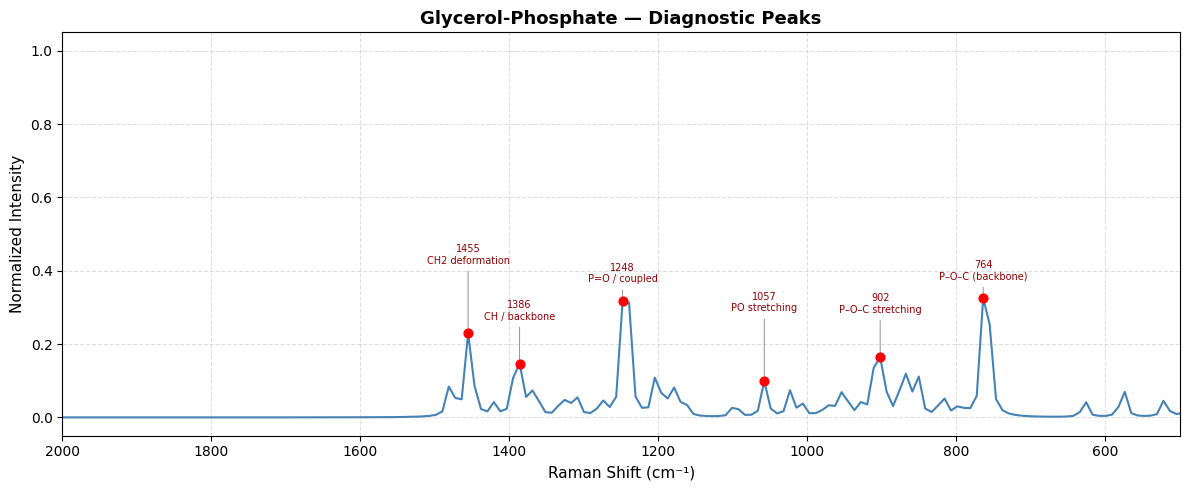

Saved: gp_diagnostic.png  |  6 peaks marked


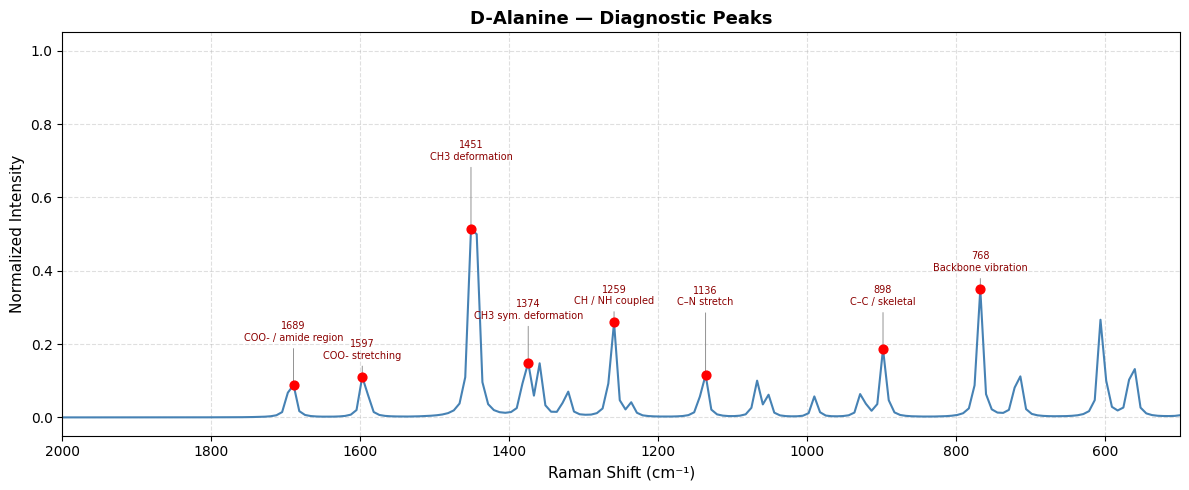

Saved: da_diagnostic.png  |  8 peaks marked


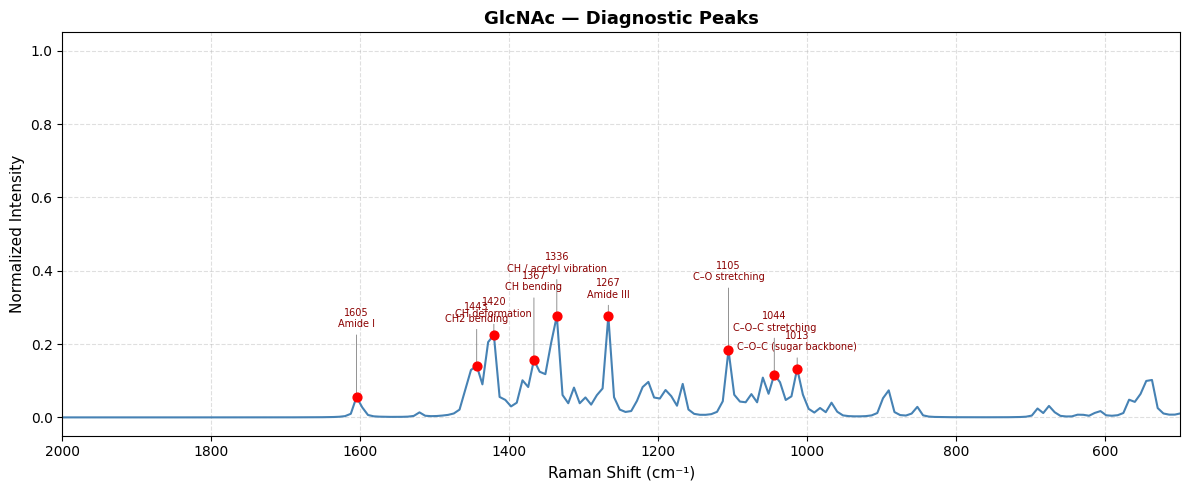

Saved: glcnac_diagnostic.png  |  9 peaks marked


In [121]:
import matplotlib.pyplot as plt
import numpy as np

diagnostic_peaks = {
    "Glycerol-Phosphate": {
        764:  "P–O–C (backbone)",
        902:  "P–O–C stretching",
        1057: "PO stretching",
        1248: "P=O / coupled",
        1386: "CH / backbone",
        1455: "CH2 deformation",
    },
    "D-Alanine": {
        768:  "Backbone vibration",
        898:  "C–C / skeletal",
        1136: "C–N stretch",
        1259: "CH / NH coupled",
        1374: "CH3 sym. deformation",
        1451: "CH3 deformation",
        1597: "COO- stretching",
        1689: "COO- / amide region",
    },
    "GlcNAc": {
        1013: "C–O–C (sugar backbone)",
        1044: "C–O–C stretching",
        1105: "C–O stretching",
        1267: "Amide III",
        1336: "CH / acetyl vibration",
        1367: "CH bending",
        1420: "CH deformation",
        1443: "CH2 bending",
        1605: "Amide I",
    },
}

def plot_diagnostic_peaks(df, label, filename, tolerance=10):
    targets = diagnostic_peaks[label]

    # Find closest detected point in spectrum for each target peak
    matched_x, matched_y, matched_label = [], [], []
    for shift, assignment in targets.items():
        diff = (df["RamanShift"] - shift).abs()
        idx = diff.idxmin()
        if diff[idx] <= tolerance:
            matched_x.append(df.loc[idx, "RamanShift"])
            matched_y.append(df.loc[idx, "Intensity_norm"])
            matched_label.append(f"{int(df.loc[idx, 'RamanShift'])}\n{assignment}")

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["RamanShift"], df["Intensity_norm"], linewidth=1.5, color="steelblue", zorder=2)

    # Markers on diagnostic peaks only
    ax.scatter(matched_x, matched_y, color="red", s=40, zorder=5)

    # Labels with alternating offsets to reduce overlap
    for i, (px, py, lbl) in enumerate(zip(matched_x, matched_y, matched_label)):
        offset = 0.05 + (i % 3) * 0.07
        ax.annotate(
            lbl,
            xy=(px, py),
            xytext=(px, py + offset),
            ha="center",
            fontsize=7,
            color="darkred",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
        )

    ax.set_xlim(2000, 500)   # Inverted, 500–2000 cm⁻¹
    ax.set_title(f"{label} — Diagnostic Peaks", fontsize=13, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=11)
    ax.set_ylabel("Normalized Intensity", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}  |  {len(matched_x)} peaks marked")

plot_diagnostic_peaks(df_gp,  "Glycerol-Phosphate", "gp_diagnostic.png")
plot_diagnostic_peaks(df_da,  "D-Alanine",           "da_diagnostic.png")
plot_diagnostic_peaks(df_glc, "GlcNAc",              "glcnac_diagnostic.png")

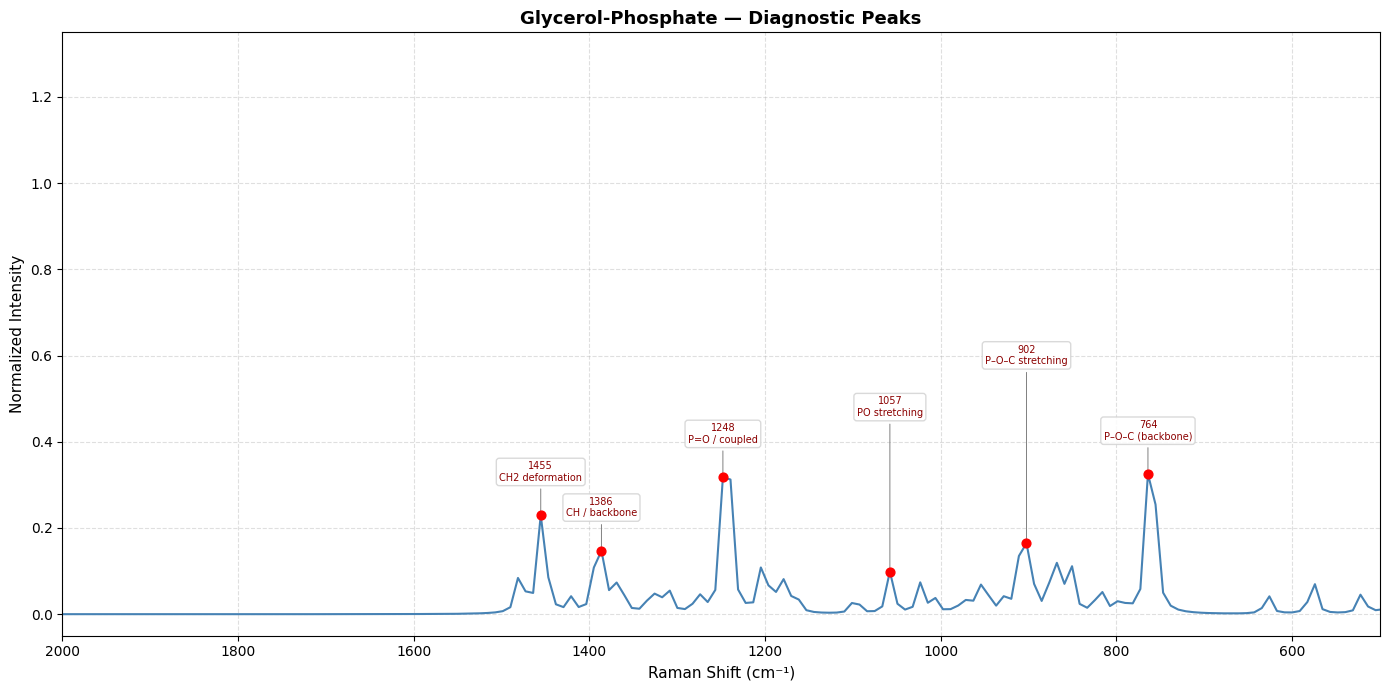

Saved: gp_diagnostic.png  |  6 peaks marked


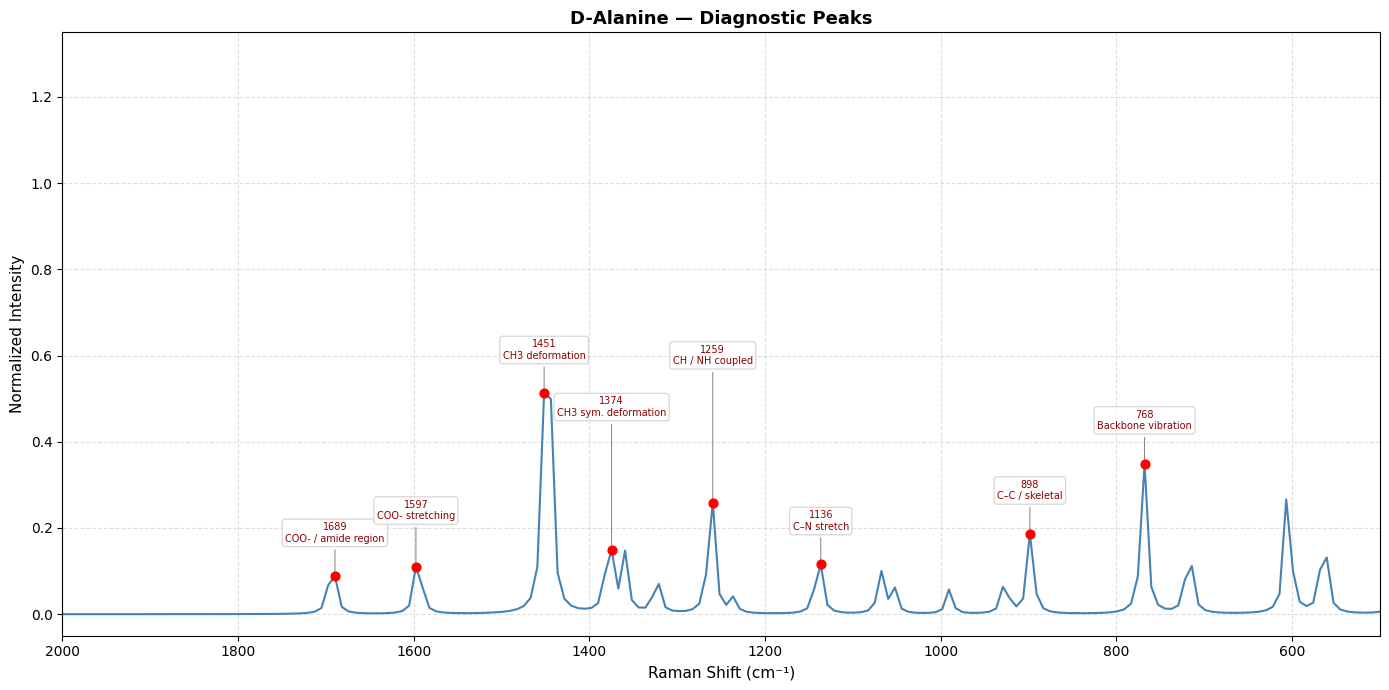

Saved: da_diagnostic.png  |  8 peaks marked


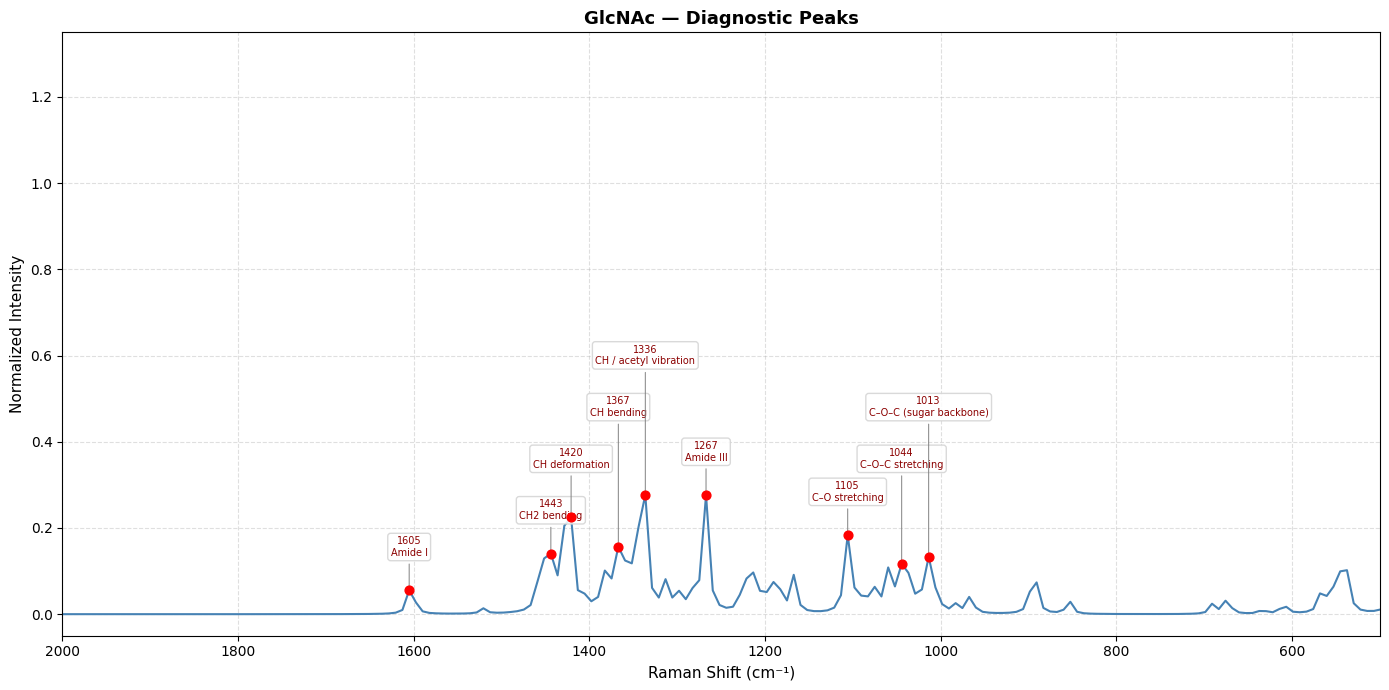

Saved: glcnac_diagnostic.png  |  9 peaks marked


In [129]:
def plot_diagnostic_peaks(df, label, filename, tolerance=10):
    targets = diagnostic_peaks[label]

    matched_x, matched_y, matched_label = [], [], []
    for shift, assignment in targets.items():
        diff = (df["RamanShift"] - shift).abs()
        idx = diff.idxmin()
        if diff[idx] <= tolerance:
            matched_x.append(df.loc[idx, "RamanShift"])
            matched_y.append(df.loc[idx, "Intensity_norm"])
            matched_label.append(f"{int(df.loc[idx, 'RamanShift'])}\n{assignment}")

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df["RamanShift"], df["Intensity_norm"], linewidth=1.5, color="steelblue", zorder=2)
    ax.scatter(matched_x, matched_y, color="red", s=40, zorder=5)

    # Fixed y-lanes: each label gets a fixed height slot, cycling through 5 levels
    y_lanes = [0.12, 0.22, 0.34, 0.46, 0.58]

    # Sort by x so lane assignment goes left to right (axis is inverted: high x = left)
    sorted_peaks = sorted(zip(matched_x, matched_y, matched_label), key=lambda t: -t[0])

    for i, (px, py, lbl) in enumerate(sorted_peaks):
        lane_y = max(py + 0.08, y_lanes[i % 5])   # never below peak, cycle lanes

        ax.annotate(
            lbl,
            xy=(px, py),
            xytext=(px, lane_y),
            ha="center",
            fontsize=7,
            color="darkred",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.7),
            bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.85, pad=2, boxstyle="round,pad=0.3"),
        )

    ax.set_xlim(2000, 500)
    ax.set_ylim(-0.05, 1.35)    # extra headroom for labels
    ax.set_title(f"{label} — Diagnostic Peaks", fontsize=13, fontweight="bold")
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=11)
    ax.set_ylabel("Normalized Intensity", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}  |  {len(matched_x)} peaks marked")

plot_diagnostic_peaks(df_gp,  "Glycerol-Phosphate", "gp_diagnostic.png")
plot_diagnostic_peaks(df_da,  "D-Alanine",           "da_diagnostic.png")
plot_diagnostic_peaks(df_glc, "GlcNAc",              "glcnac_diagnostic.png")